# SR3: revisions and the policy curve

Training: May 2018–2022. Reused validation: 2023–2024. Final holdout: 2025 onwards, excluded. No downloads.

Run all cells. Tables, plotted data, figures and trial records are written automatically.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from tools.notebook_experiments import original_eda, curve_experiment
RUN_ID = 'sr3-curve-notebook-v1'
OUT = ROOT / 'results' / RUN_ID
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .2})
print('Outputs:', OUT)

Outputs: /Users/miles/Projects/gqh-systematic-track/results/sr3-curve-notebook-v1


## Original hypothesis: distribution and IC

Histograms retain outliers. IC relates revision pressure to ten-session rate changes. Targets overlap; monthly IC requires five events. The parameter grid shows selection risk.

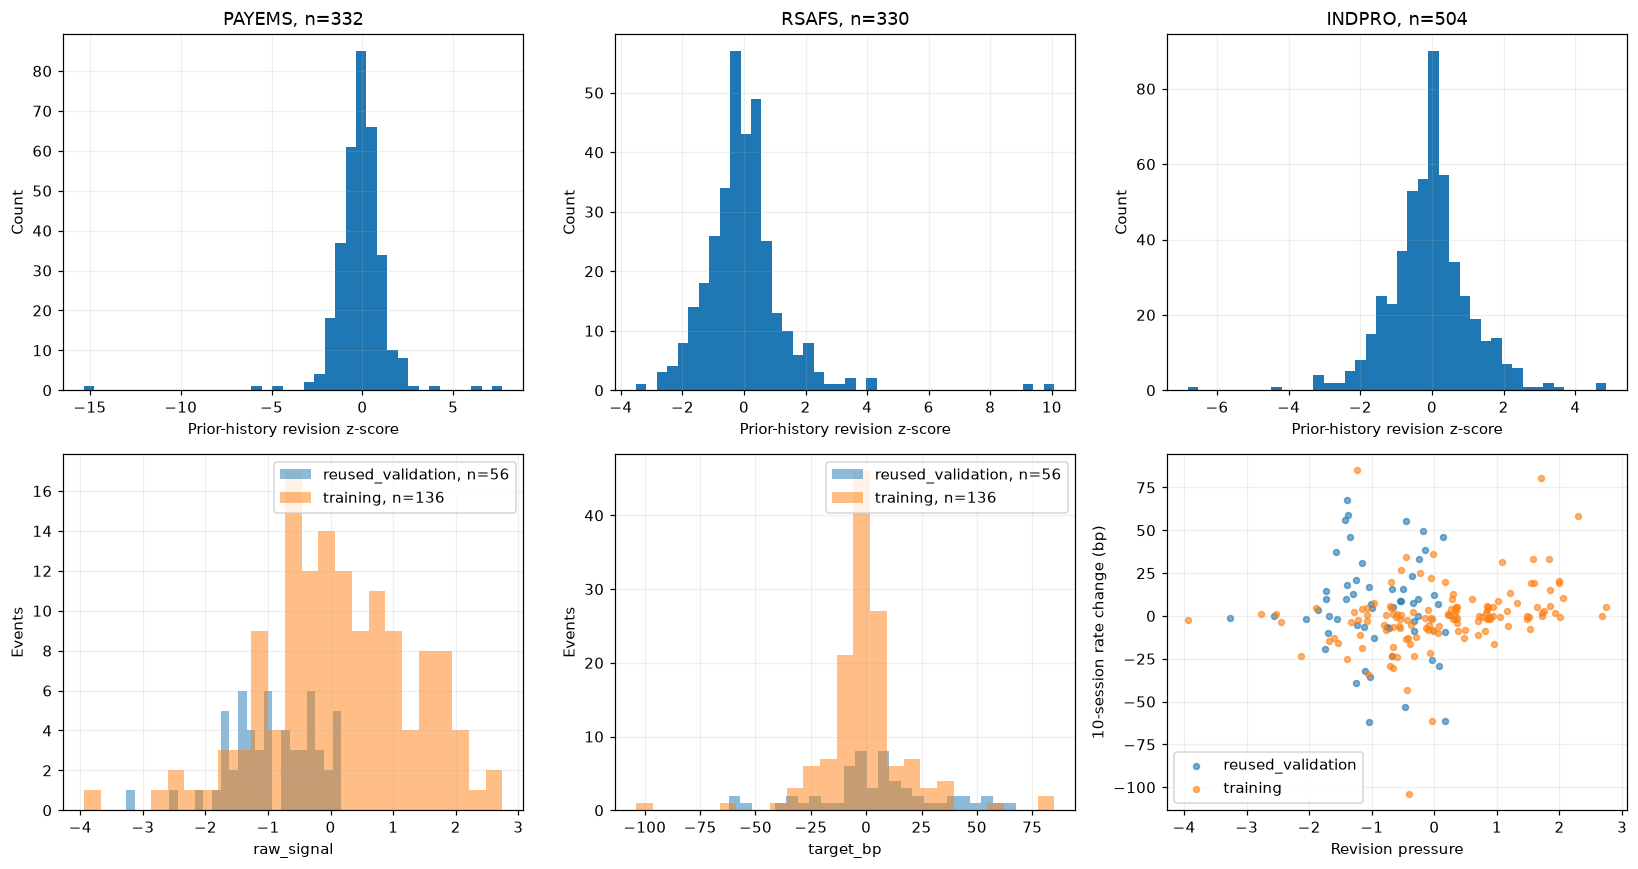

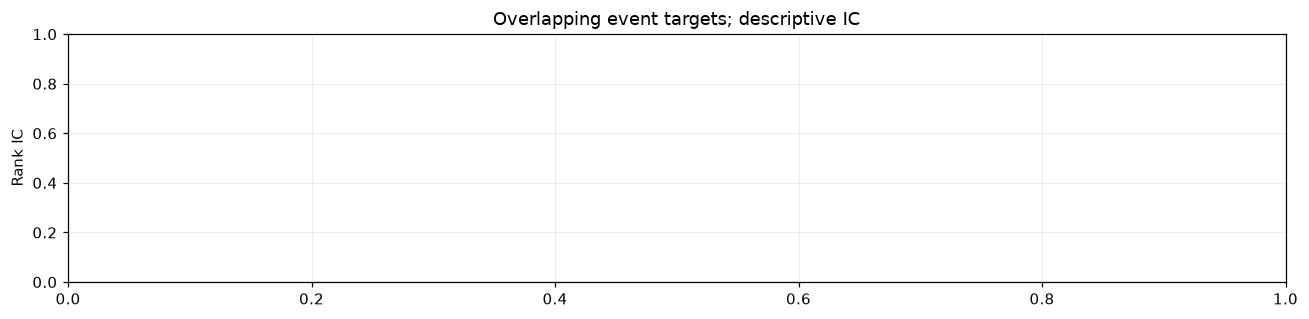

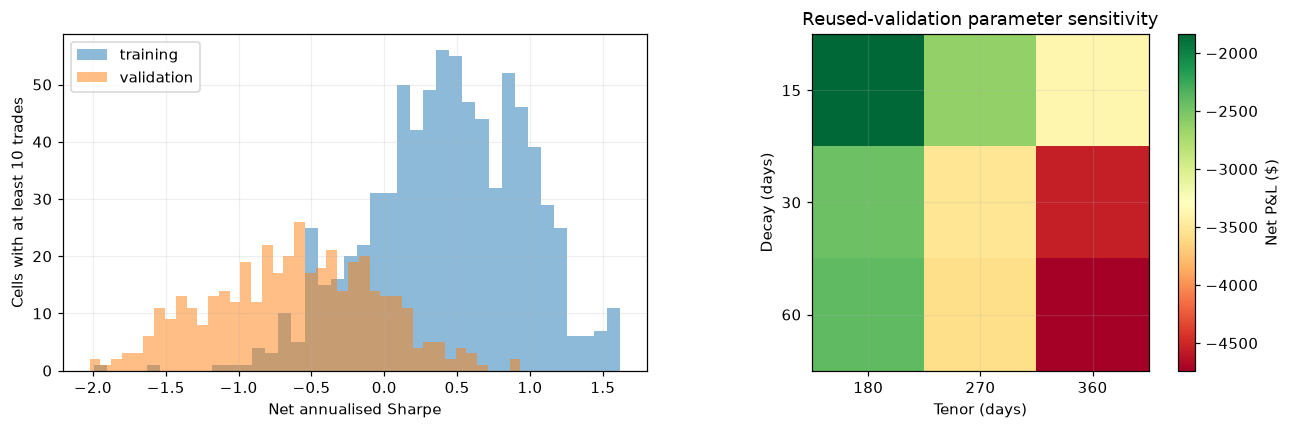

,sample,events,IC,rank_IC
0,reused_validation,56,-0.058611,-0.058109
1,training,136,0.288547,0.386816


,series,clip,decay,tenor,horizon,threshold,cost_bp,split,job_id,status,trades,net_pnl,mean_trade,win_rate,profit_factor,sharpe,max_drawdown,annual_volatility
0,"['PAYEMS', 'RSAFS', 'INDPRO']",3.0,60,360,10,1.5,1.0,training,ed0cd38b8fd50c9ecb6d,completed,16,4712.5,294.53125,0.6875,21.944444,1.293607,-0.007763,0.009609


In [2]:
display(original_eda(OUT))
display(pd.read_csv(ROOT / 'results/sr3-macro-revisions-v1/training-selected.csv'))

## Next hypothesis: curve repricing

Test twelve-month minus six-month forward-rate changes. Fixed decay: 30 days; clipping: 3; holding: 10 sessions. Ridge penalty is selected using 2021–2022 only. Positive forecasts sell the far contract and buy the near contract. Each leg pays costs. Full specification: `research/hypotheses/sr3-curve-revisions.md`.

[1/72] a0-t0.5-c0.5-training: trades=47, net=$2187.50
[2/72] a0-t0.5-c1-training: trades=47, net=$1012.50
[3/72] a0-t0.5-c2-training: trades=47, net=$-1337.50
[4/72] a0-t1-c0.5-training: trades=27, net=$1825.00
[5/72] a0-t1-c1-training: trades=27, net=$1150.00
[6/72] a0-t1-c2-training: trades=27, net=$-200.00
[7/72] a0-t1.5-c0.5-training: trades=9, net=$1000.00
[8/72] a0-t1.5-c1-training: trades=9, net=$775.00
[9/72] a0-t1.5-c2-training: trades=9, net=$325.00
[10/72] a0-t0.5-c0.5-reused_validation: trades=18, net=$-3012.50
[11/72] a0-t0.5-c1-reused_validation: trades=18, net=$-3462.50
[12/72] a0-t0.5-c2-reused_validation: trades=18, net=$-4362.50
[13/72] a0-t1-c0.5-reused_validation: trades=16, net=$-2425.00
[14/72] a0-t1-c1-reused_validation: trades=16, net=$-2825.00
[15/72] a0-t1-c2-reused_validation: trades=16, net=$-3625.00
[16/72] a0-t1.5-c0.5-reused_validation: trades=5, net=$-862.50
[17/72] a0-t1.5-c1-reused_validation: trades=5, net=$-987.50
[18/72] a0-t1.5-c2-reused_validation

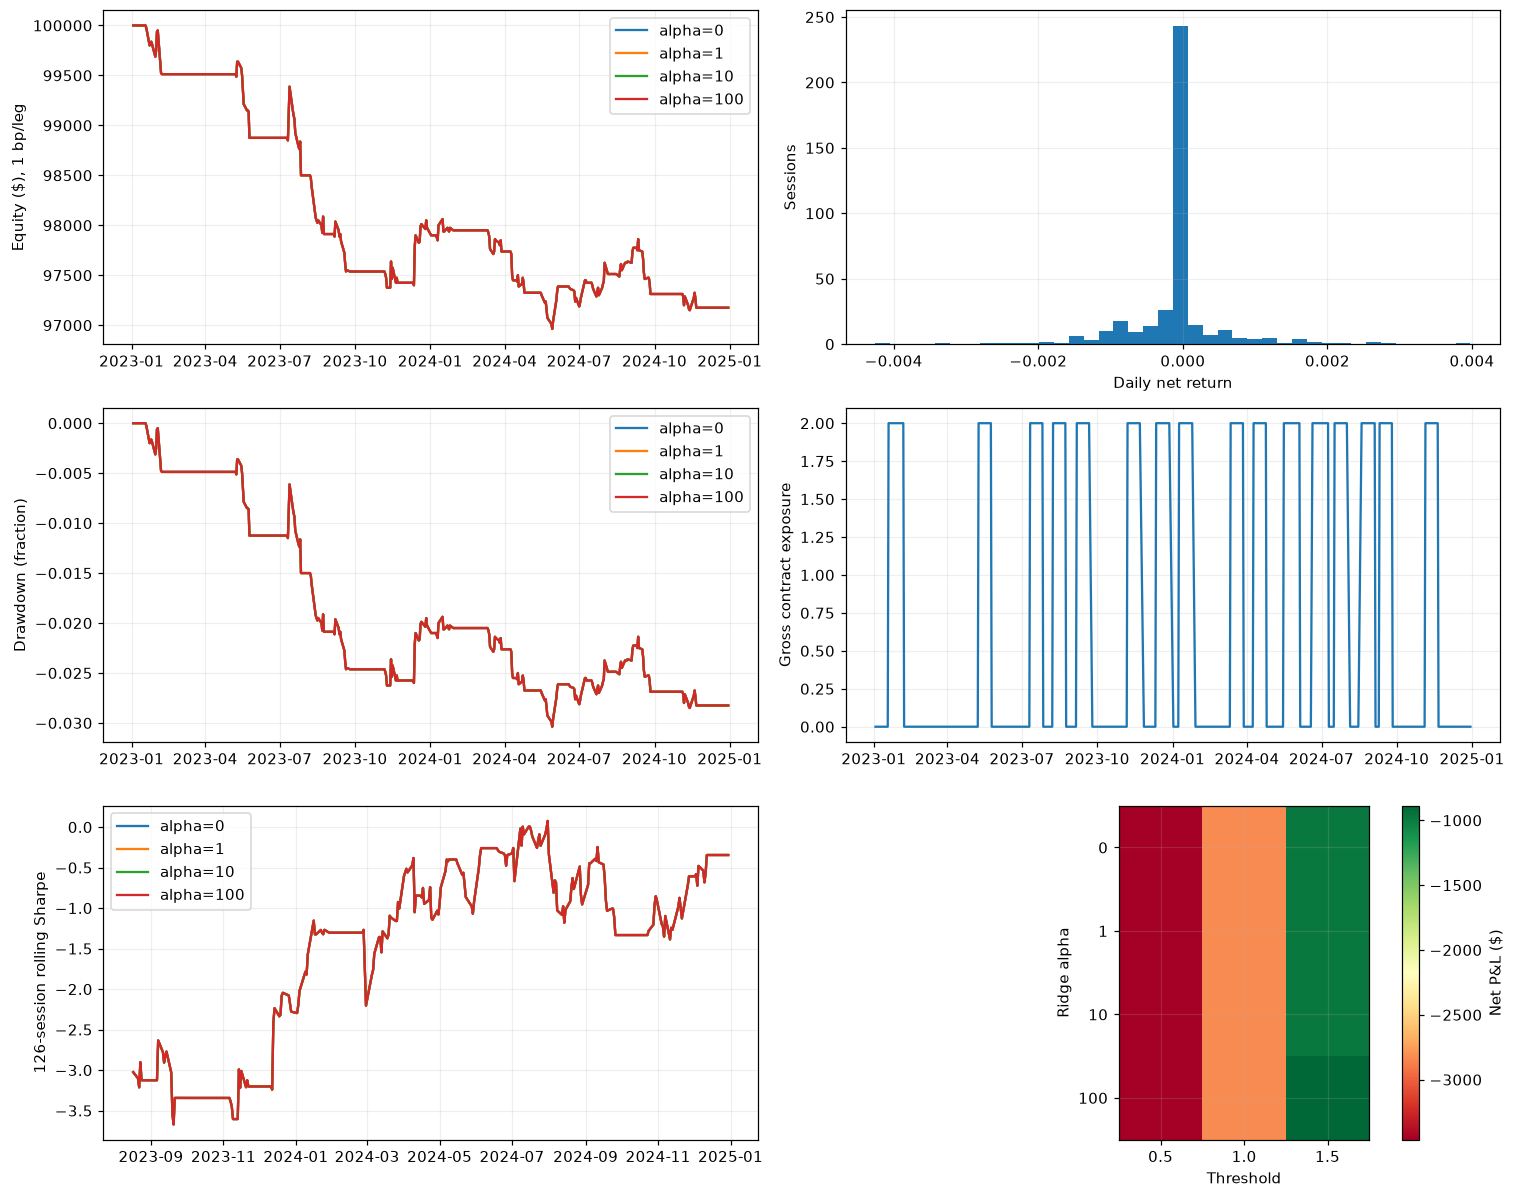

,alpha,inner_MSE,constant_MSE,inner_events
0,0,136.030062,146.091053,56
1,1,136.142782,146.091053,56
2,10,137.055418,146.091053,56
3,100,141.394045,146.091053,56


,alpha,sample,beta,MSE,constant_MSE,events,IC,rank_IC
0,0,training,2.545133,72.656149,79.133853,136,0.286108,0.315172
1,0,reused_validation,2.545133,204.945829,180.418536,56,-0.147218,-0.159907
2,1,training,2.526556,72.656494,79.133853,136,0.286108,0.315172
3,1,reused_validation,2.526556,204.709782,180.418536,56,-0.147218,-0.159907
4,10,training,2.370809,72.686538,79.133853,136,0.286108,0.315172
5,10,reused_validation,2.370809,202.763844,180.418536,56,-0.147218,-0.159907
6,100,training,1.466687,73.819196,79.133853,136,0.286108,0.315172
7,100,reused_validation,1.466687,192.631523,180.418536,56,-0.147218,-0.159907


,job_id,alpha,threshold,cost_bp_per_leg,sample,mean_gross_contract_exposure,turnover_contracts,trades,net_pnl,mean_trade,win_rate,profit_factor,sharpe,max_drawdown,annual_volatility
10,a0-t0.5-c1-reused_validation,0,0.5,1.0,reused_validation,0.904523,72,18,-3462.5,-192.361111,0.333333,0.173134,-1.876165,-0.036080,0.011854
13,a0-t1-c1-reused_validation,0,1.0,1.0,reused_validation,0.804020,64,16,-2825.0,-176.562500,0.375000,0.256579,-1.623919,-0.030375,0.011135
16,a0-t1.5-c1-reused_validation,0,1.5,1.0,reused_validation,0.251256,20,5,-987.5,-197.500000,0.200000,0.070588,-1.404192,-0.012110,0.004468
28,a1-t0.5-c1-reused_validation,1,0.5,1.0,reused_validation,0.904523,72,18,-3462.5,-192.361111,0.333333,0.173134,-1.876165,-0.036080,0.011854
31,a1-t1-c1-reused_validation,1,1.0,1.0,reused_validation,0.804020,64,16,-2825.0,-176.562500,0.375000,0.256579,-1.623919,-0.030375,0.011135
34,a1-t1.5-c1-reused_validation,1,1.5,1.0,reused_validation,0.251256,20,5,-987.5,-197.500000,0.200000,0.070588,-1.404192,-0.012110,0.004468
46,a10-t0.5-c1-reused_validation,10,0.5,1.0,reused_validation,0.904523,72,18,-3462.5,-192.361111,0.333333,0.173134,-1.876165,-0.036080,0.011854
49,a10-t1-c1-reused_validation,10,1.0,1.0,reused_validation,0.804020,64,16,-2825.0,-176.562500,0.375000,0.256579,-1.623919,-0.030375,0.011135
52,a10-t1.5-c1-reused_validation,10,1.5,1.0,reused_validation,0.251256,20,5,-987.5,-197.500000,0.200000,0.070588,-1.404192,-0.012110,0.004468
64,a100-t0.5-c1-reused_validation,100,0.5,1.0,reused_validation,0.904523,72,18,-3462.5,-192.361111,0.333333,0.173134,-1.876165,-0.036080,0.011854


In [3]:
metrics, forecasts, selection = curve_experiment(OUT)
display(selection)
display(forecasts)
display(metrics[(metrics['sample'] == 'reused_validation') & (metrics.cost_bp_per_leg == 1)].sort_values(['alpha', 'threshold']))

## Cost sensitivity and annual contribution

cost_bp_per_leg,0.5,1.0,2.0
alpha,,,
0,-2425.0,-2825.0,-3625.0
1,-2425.0,-2825.0,-3625.0
10,-2425.0,-2825.0,-3625.0
100,-2425.0,-2825.0,-3625.0


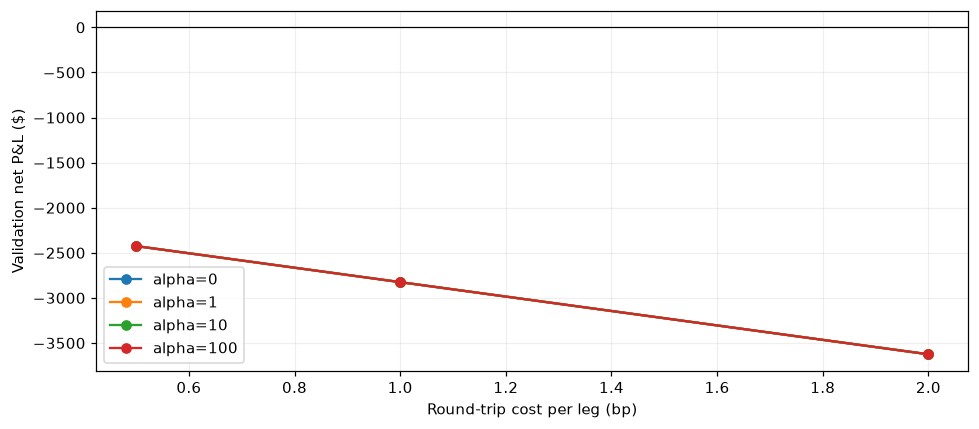

,net_pnl,sessions,mean_exposure
year,,,
2023,-2025.0,199,0.703518
2024,-800.0,199,0.904523


In [4]:
grid = metrics[metrics['sample'].eq('reused_validation') & metrics.threshold.eq(1)].pivot(index='alpha', columns='cost_bp_per_leg', values='net_pnl')
display(grid)
fig, ax = plt.subplots(figsize=(9, 4))
for alpha, row in grid.iterrows():
    ax.plot(grid.columns, row, marker='o', label=f'alpha={alpha}')
ax.axhline(0, color='black', lw=.8)
ax.set(xlabel='Round-trip cost per leg (bp)', ylabel='Validation net P&L ($)')
ax.legend(); fig.tight_layout(); fig.savefig(OUT / 'figures/cost-sensitivity.png', dpi=150); plt.show()
grid.to_csv(OUT / 'cost-sensitivity.csv')
chosen = int(selection.sort_values(['inner_MSE', 'alpha']).iloc[0].alpha)
r = pd.read_csv(OUT / f'returns-a{chosen}-t1-c1-reused_validation.csv')
r['year'] = pd.to_datetime(r.date).dt.year
yearly = r.groupby('year').agg(net_pnl=('pnl','sum'), sessions=('pnl','size'), mean_exposure=('gross_contract_exposure','mean'))
yearly.to_csv(OUT / 'annual-contributions.csv'); display(yearly)

## Decision

Compare forecast MSE with the constant baseline; inspect IC, coefficient sign, trade count, costs and neighbouring thresholds. A positive cell selected after viewing validation is exploratory. Further confirmatory testing requires a frozen specification and separate holdout access.

In [5]:
print((OUT / 'REPORT.md').read_text())
print('Saved:', OUT)

# SR3 curve revisions

Inner-selected ridge penalty: 0

                    job_id  alpha  threshold  cost_bp_per_leg            sample  mean_gross_contract_exposure  turnover_contracts  trades  net_pnl  mean_trade  win_rate  profit_factor    sharpe  max_drawdown  annual_volatility
         a0-t1-c1-training      0        1.0              1.0          training                      0.576307                 108      27   1150.0   42.592593   0.37037       1.666667  0.441580     -0.009938           0.007020
a0-t1-c1-reused_validation      0        1.0              1.0 reused_validation                      0.804020                  64      16  -2825.0 -176.562500   0.37500       0.256579 -1.623919     -0.030375           0.011135

2023–2024 is reused validation. Holdout untouched. Event targets overlap; IC is descriptive. Fills and two-leg execution are modelled.

Saved: /Users/miles/Projects/gqh-systematic-track/results/sr3-curve-notebook-v1
